In [14]:
import os
import sys
import json
import numpy as np
# sys.path.append("/Users/christina/code/RockPaperScissors_backup/modules")
from utils import get_video_metadata, get_cropped_video_indices, load_splits_cropped, ALIGN_DIR
from get_frames import get_video_csv, get_frame_landmarks
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [20]:
BASE_DIR = "/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2"
CSV_FILE_NAME = "img_landmarks_norm"
metadata_files_all = get_video_metadata(BASE_DIR)

paper: 13 image directories found.
rock: 13 image directories found.
scissors: 13 image directories found.


In [21]:
def pad_landmark_frames_to_match_video_frames(
    landmarks, mp_idx, real_idx, action_onset_frame
) -> np.ndarray:
    """Pad a landmarks array so its first axis aligns with real_idx.

    For each frame in `real_idx` missing from `mp_idx`, this function inserts a copy
    of the *next* available landmark row. If the missing frame lies after the last
    mp_idx, it copies the previous available row instead.

    Args:
        landmarks: np.ndarray of shape (M, L, 3) where M == len(mp_idx)
        mp_idx: sequence of M increasing frame indices where landmarks were detected
        real_idx: sequence of N increasing frame indices representing real video frames

    Returns:
        np.ndarray of shape (N, L, 3) where rows corresponding to frames not in
        mp_idx are filled by copying the next available landmark row (or previous
        if missing at the end).
    """
    mp_idx = np.asarray(mp_idx, dtype=int)
    real_idx = np.asarray(real_idx, dtype=int)

    if landmarks.shape[0] != len(mp_idx):
        raise ValueError("landmarks.shape[0] must equal len(mp_idx)")

    # If no missing frames, quick return
    missing = sorted(set(real_idx) - set(mp_idx))
    if not missing:
        # If mp_idx is a subset but in same order as real_idx, we still may need to
        # expand by placing rows at the correct real positions. We'll build a full
        # buffer below (fast path would be possible but this is clearer).
        pass

    # Build an output buffer initialized with NaNs
    N = len(real_idx)
    L = landmarks.shape[1]
    C = landmarks.shape[2]
    out = np.full((N, L, C), np.nan, dtype=landmarks.dtype)

    # Create a map from mp_idx value -> row index in landmarks
    mp_to_row = {int(v): i for i, v in enumerate(mp_idx)}

    # Check mp_idx position relative to action_onset frame
    
    
    # Iterate over real_idx and fill from landmarks
    for out_i, frame in enumerate(real_idx):
        #if frame < action_onset_frame:
            
        if frame in mp_to_row:
            out[out_i] = landmarks[mp_to_row[frame]]
        else:
            # missing frame: find the insert position in mp_idx (first mp_idx > frame)
            insert_pos = np.searchsorted(mp_idx, frame, side="left")
            if insert_pos < len(mp_idx):
                # copy the next available landmark row
                src_row = insert_pos
                out[out_i] = landmarks[src_row]
            else:
                # missing frame is after last mp_idx: copy the last available row
                out[out_i] = landmarks[-1]

    return out


def find_average_sample_across_videos(class_metadata_files, csv_file_name="img_landmarks") -> np.ndarray:
    all_class_landmarks = []
    vid_names = []
    for meta_file in class_metadata_files: 
        print(f"Processing {meta_file}...")
        with open(meta_file, "r") as f:
            data = json.load(f)
        start, onset, end, _ = get_cropped_video_indices(data)
        vid_name = meta_file.split('/')[-2]
        landmarks_df = get_video_csv(BASE_DIR, vid_name, csv_file_name)
        landmarks_df_cropped = landmarks_df[(landmarks_df["frame_idx"] >= start) & (landmarks_df["frame_idx"] <= end)]
        
        real_indices = np.arange(start, end + 1)
        mediapipe_indices = landmarks_df_cropped.groupby("frame_idx")['frame_idx'].apply(list).index.to_numpy()
    
        landmarks = landmarks_df_cropped[['x_world_m', 'y_world_m', 'z_world_m']].to_numpy().reshape(-1, 21, 3)
        print(f"Landmarks shape: {landmarks.shape}")
        action_onset_frame = data['action_frame_idx']
        landmarks_padded = pad_landmark_frames_to_match_video_frames(landmarks, mediapipe_indices, real_indices, action_onset_frame)
        
        print(f"Padded landmarks shape: {landmarks_padded.shape}")
        
        #all_class_landmarks.append(landmarks)
        all_class_landmarks.append(landmarks_padded)
        vid_names.append(vid_name)
        print()
        
    # Pad landmarks to the max length
    max_length = max(landmarks.shape[0] for landmarks in all_class_landmarks)
    print(f"padding to max length: {max_length}")
    #all_class_landmarks = [np.pad(landmarks, ((0, max_length - landmarks.shape[0]), (0, 0), (0, 0)), mode='edge') for landmarks in all_class_landmarks]

    # Stack all landmarks for this class
    all_class_landmarks = np.array(all_class_landmarks)  # (n_videos, n_frames, n_landmarks, 3)
    prototype_landmarks = np.nanmean(all_class_landmarks, axis=0)  # (n_landmarks, 3)
    
    print()
    print(f"    All stacked landmarks shape: {all_class_landmarks.shape}")
    print(f"    Prototype landmarks shape: {prototype_landmarks.shape}")
    print()
    
    return prototype_landmarks, all_class_landmarks, vid_names


## 1

In [22]:
dists_per_class = {}
all_landmarks = []

for gesture_class in ["rock", "paper", "scissors"]:
    dists_per_class[gesture_class] = {}
    
    metadata_files_class = [f for f in metadata_files_all if f"{os.sep}{gesture_class}{os.sep}" in f]
    print(f"\n===== Number of {gesture_class} videos: {len(metadata_files_class)} =====")
    
    prototype_landmarks, all_class_landmarks, vid_names = find_average_sample_across_videos(metadata_files_class, CSV_FILE_NAME) #(n_landmarks, 3)
    all_landmarks.extend(all_class_landmarks)
    
    pairwise_dists = [np.linalg.norm(landmarks_vid_i - prototype_landmarks) for landmarks_vid_i in all_class_landmarks]
    print(f" 🔫 Distances from prototype shape: {pairwise_dists}")
    
    dists_per_class[gesture_class]["distances"] = pairwise_dists
    dists_per_class[gesture_class]["prototype"] = prototype_landmarks
    dists_per_class[gesture_class]["all_landmarks"] = all_class_landmarks
    dists_per_class[gesture_class]["vid_names"] = vid_names
    dists_per_class[gesture_class]["min_dist_to_prot"] = vid_names[np.argmin(pairwise_dists)]



===== Number of rock videos: 12 =====
Processing /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_18/metadata.json...
Reading CSV file at: /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_18/img_landmarks_norm.csv
Landmarks shape: (13, 21, 3)
Padded landmarks shape: (13, 21, 3)

Processing /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_6/metadata.json...
Reading CSV file at: /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_6/img_landmarks_norm.csv
Landmarks shape: (13, 21, 3)
Padded landmarks shape: (13, 21, 3)

Processing /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_32/metadata.json...
Reading CSV file at: /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_32/img_landmarks_norm.csv
Landmarks shape: (13, 21, 3)
Padded landmarks shape: (13, 21, 3)

Processing /Users/christina

In [23]:
prototype_rock = dists_per_class['rock']['prototype']
prototype_paper = dists_per_class['paper']['prototype']
prototype_scissors = dists_per_class['scissors']['prototype']

In [24]:
import plotly.graph_objects as go
colors = {'rock': '#52B53C', 'paper': '#2F38BD', 'scissors': '#F54927'}

fig = go.Figure()
for gesture_class, info in dists_per_class.items():
    for landmarks_i in info["all_landmarks"]:
        dist_to_rock = np.linalg.norm(landmarks_i - prototype_rock)
        dist_to_paper = np.linalg.norm(landmarks_i - prototype_paper)
        dist_to_scissors = np.linalg.norm(landmarks_i - prototype_scissors)
        fig.add_trace(go.Scatter3d(
            x=[dist_to_rock], y=[dist_to_paper], z=[dist_to_scissors],
            mode='markers',
            marker=dict(color=colors[gesture_class]),
            name=gesture_class
        ))
fig.update_layout(scene=dict(
    xaxis_title='Distance to Rock Prototype',
    yaxis_title='Distance to Paper Prototype',
    zaxis_title='Distance to Scissors Prototype'
))
fig.show()

## 2

In [25]:
dists_per_class = {}
all_landmarks = []

for gesture_class in ["rock", "paper", "scissors"]:
    dists_per_class[gesture_class] = {}
    
    metadata_files_class = [f for f in metadata_files_all if f"{os.sep}{gesture_class}{os.sep}" in f]
    print(f"\n===== Number of {gesture_class} videos: {len(metadata_files_class)} =====")
    
    prototype_landmarks, all_class_landmarks, vid_names = find_average_sample_across_videos(metadata_files_class, CSV_FILE_NAME) #(n_landmarks, 3)
    all_landmarks.extend(all_class_landmarks)

    pairwise_dists = np.array([np.linalg.norm(landmarks_vid_i - prototype_landmarks, axis=(1, 2)) for landmarks_vid_i in all_class_landmarks])
    print(f" 🔫 Distances from prototype shape: {pairwise_dists}")
    

    dists_per_class[gesture_class]["distances"] = pairwise_dists
    dists_per_class[gesture_class]["prototype"] = prototype_landmarks
    dists_per_class[gesture_class]["all_landmarks"] = all_class_landmarks
    dists_per_class[gesture_class]["vid_names"] = vid_names
    dists_per_class[gesture_class]["min_dist_to_prot"] = '' # vid_names[np.argmin(pairwise_dists)]



===== Number of rock videos: 12 =====
Processing /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_18/metadata.json...
Reading CSV file at: /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_18/img_landmarks_norm.csv
Landmarks shape: (13, 21, 3)
Padded landmarks shape: (13, 21, 3)

Processing /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_6/metadata.json...
Reading CSV file at: /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_6/img_landmarks_norm.csv
Landmarks shape: (13, 21, 3)
Padded landmarks shape: (13, 21, 3)

Processing /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_32/metadata.json...
Reading CSV file at: /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_32/img_landmarks_norm.csv
Landmarks shape: (13, 21, 3)
Padded landmarks shape: (13, 21, 3)

Processing /Users/christina

In [ ]:
pairwise_dists.shape

(12, 13)

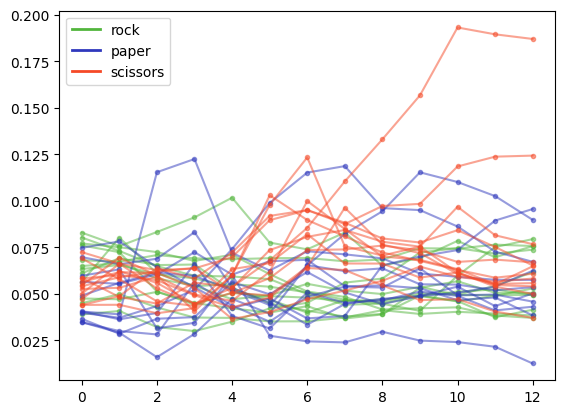

In [ ]:
import matplotlib.pyplot as plt

colors = {'rock': '#52B53C', 'paper': '#2F38BD', 'scissors': '#F54927'}

fig = plt.figure()
for gesture_class, info in dists_per_class.items():
    for landmarks_i in info["distances"]:
        plt.plot(landmarks_i, marker='.', color=colors[gesture_class], alpha=0.5)
        
legend_elements = [
    Line2D([0], [0], color=colors['rock'], lw=2, label='rock'),
    Line2D([0], [0], color=colors['paper'], lw=2, label='paper'),
    Line2D([0], [0], color=colors['scissors'], lw=2, label='scissors')
]
plt.legend(handles=legend_elements)
plt.show()

In [ ]:
prototype_rock = dists_per_class['rock']['prototype']
prototype_paper = dists_per_class['paper']['prototype']
prototype_scissors = dists_per_class['scissors']['prototype']

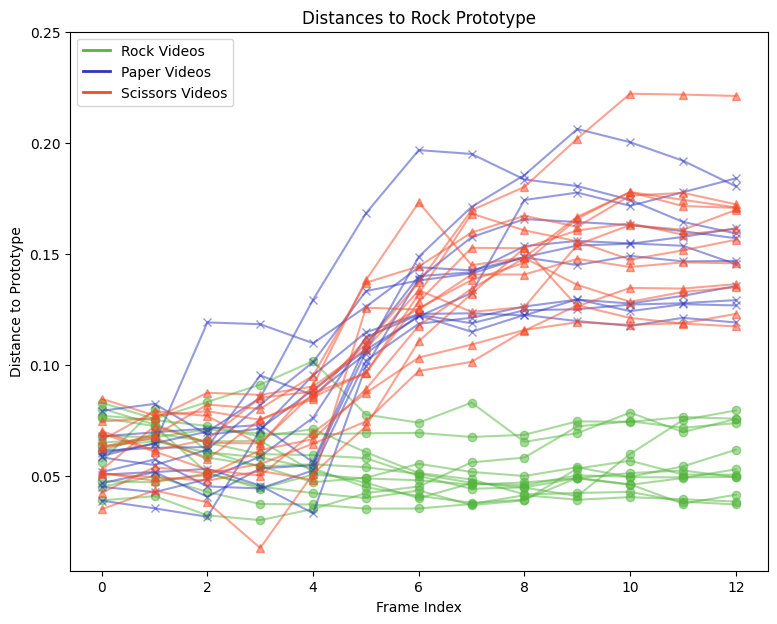

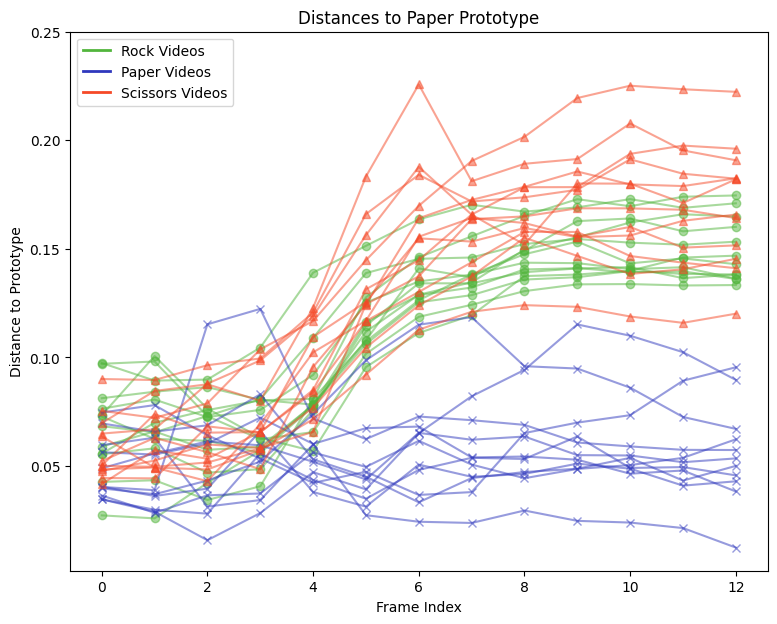

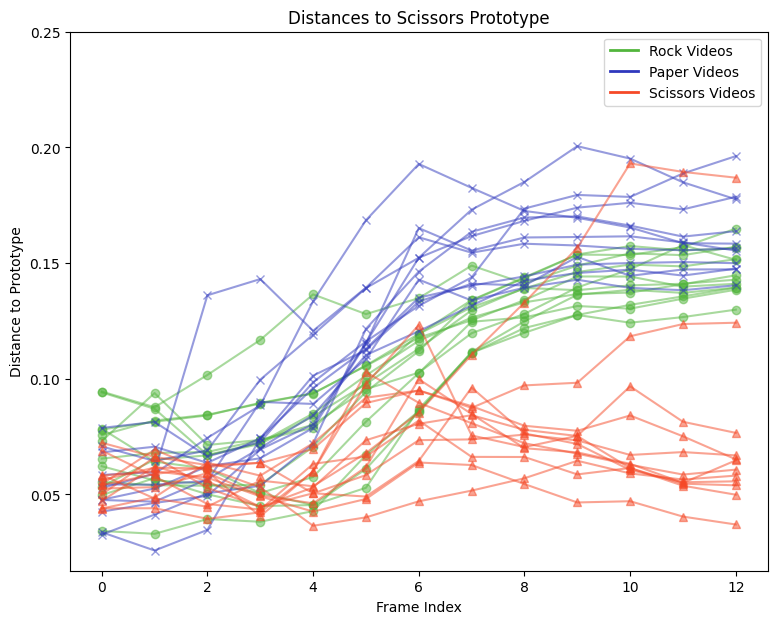

In [ ]:
import matplotlib.pyplot as plt

colors = {'rock': '#52B53C', 'paper': '#2F38BD', 'scissors': '#F54927'}
markers = {'rock': 'o', 'paper': 'x', 'scissors': '^'}

for gesture in ['rock', 'paper', 'scissors']:
    fig = plt.figure(figsize=(9, 7))
    
    for gesture_class, info in dists_per_class.items():

        # if gesture_class == gesture:
        #     continue    
        
        for landmarks_i in info["all_landmarks"]:

            dist = np.linalg.norm(landmarks_i - dists_per_class[gesture]['prototype'], axis=(1, 2))
            plt.plot(dist, marker=markers[gesture_class], color=colors[gesture_class], alpha=0.5)
            
    plt.xlabel("Frame Index")
    plt.ylabel("Distance to Prototype")
    plt.title(f"Distances to {gesture.capitalize()} Prototype")
    
    legend_elements = [
        Line2D([0], [0], color=colors['rock'],     lw=2, label='Rock Videos'),
        Line2D([0], [0], color=colors['paper'],    lw=2, label='Paper Videos'),
        Line2D([0], [0], color=colors['scissors'], lw=2, label='Scissors Videos')
    ]
    plt.ylim(top=0.25)
    plt.legend(handles=legend_elements)
    plt.show()
    #break

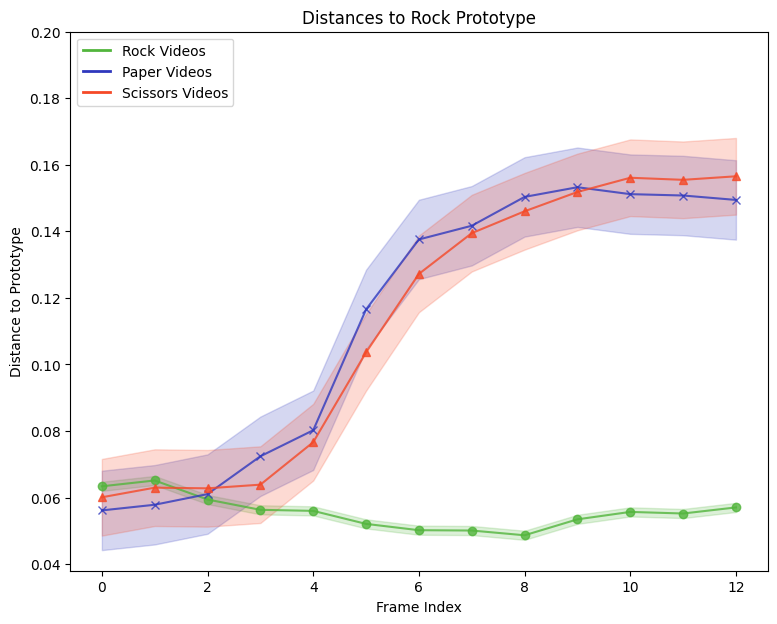

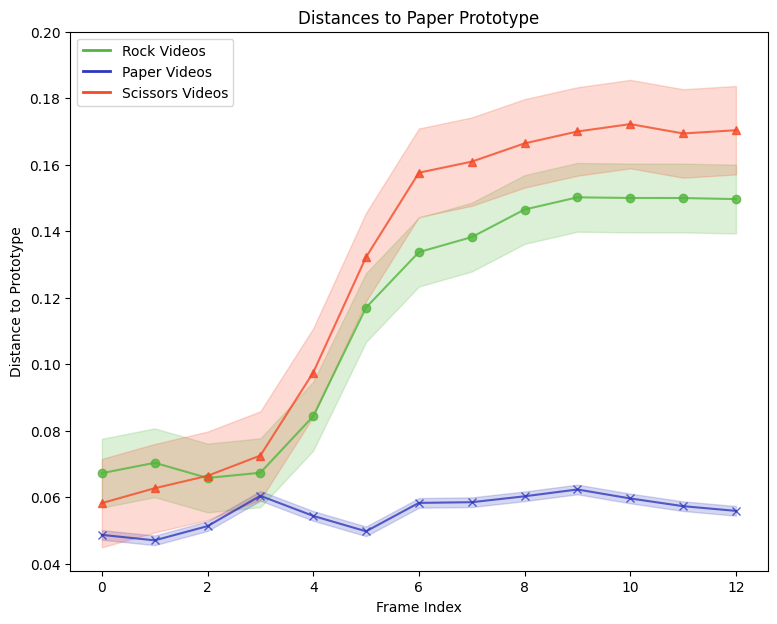

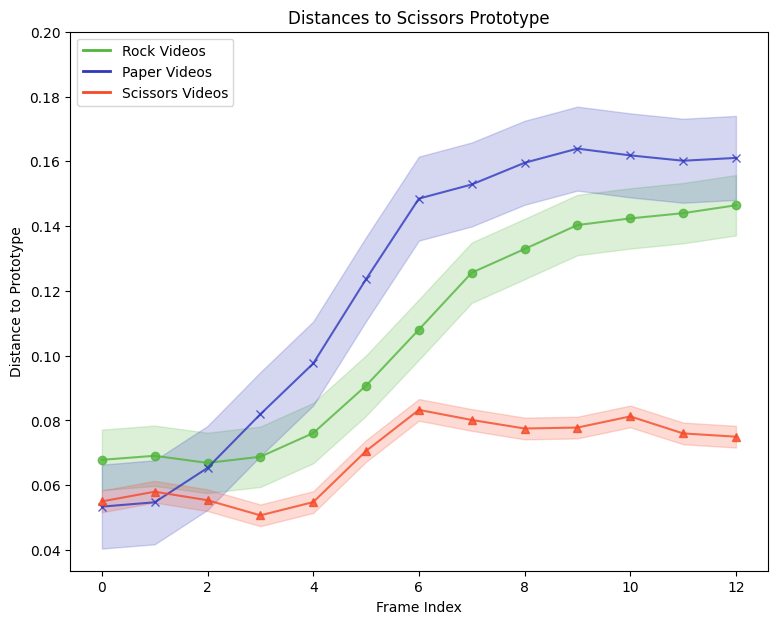

In [ ]:
import matplotlib.pyplot as plt

colors = {'rock': '#52B53C', 'paper': '#2F38BD', 'scissors': '#F54927'}
markers = {'rock': 'o', 'paper': 'x', 'scissors': '^'}

for gesture in ['rock', 'paper', 'scissors']:
    fig = plt.figure(figsize=(9, 7))
    
    for gesture_class, info in dists_per_class.items():

        dist_mean = []
        dist_sem = []
        for landmarks_i in info["all_landmarks"]:

            dist = np.linalg.norm(landmarks_i - dists_per_class[gesture]['prototype'], axis=(1, 2))
            # plt.plot(dist, marker=markers[gesture_class], color=colors[gesture_class], alpha=0.5)
            dist_mean.append(dist)
        
        dist_mean = np.mean(dist_mean, axis=0)
        dist_sem = np.std(dist_mean, axis=0) / np.sqrt(len(info["all_landmarks"]))
        plt.plot(dist_mean, marker=markers[gesture_class], color=colors[gesture_class], alpha=0.8, label=gesture_class)
        plt.fill_between(np.arange(len(dist_mean)), dist_mean - dist_sem, dist_mean + dist_sem, color=colors[gesture_class], alpha=0.2)        
    
    plt.xlabel("Frame Index")
    plt.ylabel("Distance to Prototype")
    plt.title(f"Distances to {gesture.capitalize()} Prototype")
    
    legend_elements = [
        Line2D([0], [0], color=colors['rock'],     lw=2, label='Rock Videos'),
        Line2D([0], [0], color=colors['paper'],    lw=2, label='Paper Videos'),
        Line2D([0], [0], color=colors['scissors'], lw=2, label='Scissors Videos')
    ]
    plt.ylim(top=0.2)
    plt.legend(handles=legend_elements, loc='upper left')
    plt.show()
